In [1]:
# 1. ИМПОРТЫ И НАСТРОЙКИ

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms

# Воспроизводимость
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Устройство
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Torch: {torch.__version__}')

# Пути для артефактов
ARTIFACTS_DIR = './artifacts'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

Device: cuda
Torch: 2.7.1+cu118


In [2]:
# 2. ДАННЫЕ: EMNIST (Вариант B - digits)

# Трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Загрузка датасета EMNIST (split='digits' - 10 классов цифр, как MNIST)
train_full = datasets.EMNIST(
    root='./data', 
    split='digits',
    train=True, 
    download=True, 
    transform=transform
)
test_ds = datasets.EMNIST(
    root='./data', 
    split='digits',
    train=False, 
    download=True, 
    transform=transform
)

# Разбиение train/val (80/20)
val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(train_full, [train_size, val_size], generator=generator)

# DataLoader
BATCH_SIZE = 128
NUM_WORKERS = 0

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Sanity check
x_batch, y_batch = next(iter(train_loader))
print(f'x_batch: {x_batch.shape}, {x_batch.dtype}')
print(f'y_batch: {y_batch.shape}, {y_batch.dtype}')

INPUT_DIM = 28 * 28  # 784
NUM_CLASSES = 10  # EMNIST digits имеет 10 классов (0-9)

x_batch: torch.Size([128, 1, 28, 28]), torch.float32
y_batch: torch.Size([128]), torch.int64


In [3]:
# 3. МОДЕЛЬ: MLP

class MLP(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, 
                 hidden_dims: Tuple[int] = (256, 128),
                 dropout_p: float = 0.0,
                 use_batchnorm: bool = False,
                 activation: str = 'relu'):
        super().__init__()
        
        layers = [nn.Flatten()]
        prev = input_dim
        
        act_fn = nn.ReLU() if activation == 'relu' else nn.Tanh()
        
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_fn)
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [4]:
# 4. ЦИКЛ ОБУЧЕНИЯ
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n_batches = 0.0, 0.0, 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n_batches += 1
    
    return total_loss / n_batches, total_acc / n_batches

# EarlyStopping
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0
    
    def step(self, score: float, model: nn.Module) -> bool:
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience
    
    def restore_best(self, model: nn.Module):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

# Fit функция
def fit(model, train_loader, val_loader, optimizer, criterion, device, 
        epochs: int = 20, early_stopping: Optional[EarlyStopping] = None, verbose: bool = True):
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'epochs': []}
    
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        history['epochs'].append(epoch)
        
        if verbose:
            print(f'Epoch {epoch:02d}| train loss={tr_loss:.4f}, acc={tr_acc:.3f}| val loss={va_loss:.4f}, acc={va_acc:.3f}')
        
        if early_stopping is not None:
            if early_stopping.step(va_acc, model):
                if verbose:
                    print(f'EarlyStopping at epoch {epoch}. Best val_acc={early_stopping.best_score:.4f}')
                early_stopping.restore_best(model)
                break
    
    return history

def plot_history(history: dict, title: str = '', save_path: Optional[str] = None):
    epochs = history['epochs']
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title(f'{title} | Loss')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label='train_acc')
    plt.plot(epochs, history['val_acc'], label='val_acc')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title(f'{title} | Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f'Saved: {save_path}')
    plt.show()


E1: Base MLP (no Dropout, no BatchNorm)
Epoch 01| train loss=0.1765, acc=0.948| val loss=0.0856, acc=0.975
Epoch 02| train loss=0.0730, acc=0.978| val loss=0.0633, acc=0.981
Epoch 03| train loss=0.0567, acc=0.983| val loss=0.0538, acc=0.984
Epoch 04| train loss=0.0474, acc=0.986| val loss=0.0555, acc=0.984
Epoch 05| train loss=0.0412, acc=0.987| val loss=0.0472, acc=0.987
Epoch 06| train loss=0.0362, acc=0.989| val loss=0.0474, acc=0.986
Epoch 07| train loss=0.0314, acc=0.990| val loss=0.0487, acc=0.986
Epoch 08| train loss=0.0290, acc=0.991| val loss=0.0481, acc=0.987
Epoch 09| train loss=0.0265, acc=0.991| val loss=0.0496, acc=0.987
Epoch 10| train loss=0.0242, acc=0.992| val loss=0.0503, acc=0.988
Epoch 11| train loss=0.0219, acc=0.993| val loss=0.0528, acc=0.986
Epoch 12| train loss=0.0210, acc=0.993| val loss=0.0504, acc=0.988
Epoch 13| train loss=0.0191, acc=0.994| val loss=0.0551, acc=0.988
Epoch 14| train loss=0.0184, acc=0.994| val loss=0.0626, acc=0.986
Epoch 15| train loss=

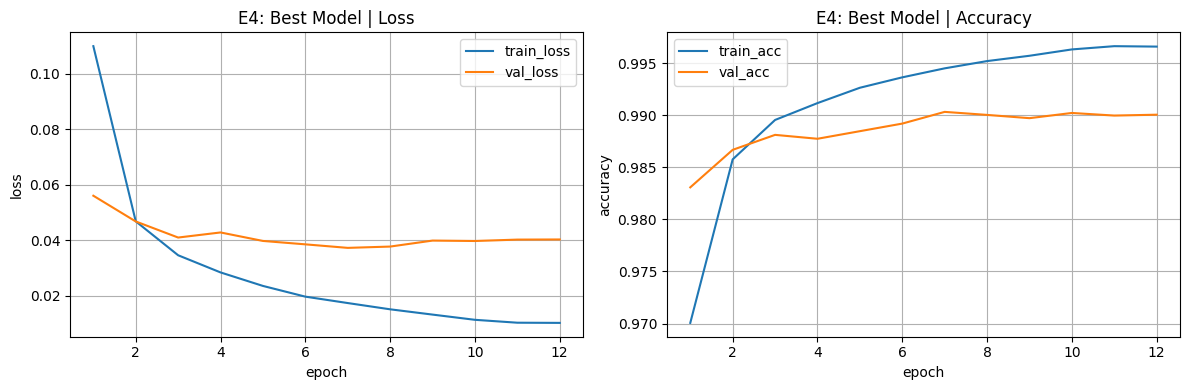

In [5]:
# 5. ЭКСПЕРИМЕНТЫ ЧАСТИ A (S08): РЕГУЛЯРИЗАЦИЯ

all_results = []
criterion = nn.CrossEntropyLoss()

# E1: Base (без регуляризации)
print('\n' + '='*60)
print('E1: Base MLP (no Dropout, no BatchNorm)')
print('='*60)

set_seed = lambda: (random.seed(SEED), np.random.seed(SEED), torch.manual_seed(SEED))
set_seed()

model_e1 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=False).to(DEVICE)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=1e-3)
history_e1 = fit(model_e1, train_loader, val_loader, optimizer_e1, criterion, DEVICE, epochs=20, verbose=True)
test_loss_e1, test_acc_e1 = evaluate(model_e1, test_loader, criterion, DEVICE)

all_results.append({
    'experiment_id': 'E1', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': '256-128/relu/noDO/noBN', 'optimizer': 'Adam', 'lr': 1e-3,
    'momentum': 0, 'weight_decay': 0, 'epochs_trained': 20,
    'best_val_accuracy': max(history_e1['val_acc']), 'best_val_loss': min(history_e1['val_loss']),
    'test_accuracy': test_acc_e1
})
print(f'E1 Test: acc={test_acc_e1:.4f}')

# E2: Dropout
print('\n' + '='*60)
print('E2: MLP + Dropout (p=0.3)')
print('='*60)

set_seed()
model_e2 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=False).to(DEVICE)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=1e-3)
history_e2 = fit(model_e2, train_loader, val_loader, optimizer_e2, criterion, DEVICE, epochs=20, verbose=True)
test_loss_e2, test_acc_e2 = evaluate(model_e2, test_loader, criterion, DEVICE)

all_results.append({
    'experiment_id': 'E2', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': '256-128/relu/DO0.3/noBN', 'optimizer': 'Adam', 'lr': 1e-3,
    'momentum': 0, 'weight_decay': 0, 'epochs_trained': 20,
    'best_val_accuracy': max(history_e2['val_acc']), 'best_val_loss': min(history_e2['val_loss']),
    'test_accuracy': test_acc_e2
})
print(f'E2 Test: acc={test_acc_e2:.4f}')

# E3: BatchNorm
print('\n' + '='*60)
print('E3: MLP + BatchNorm')
print('='*60)

set_seed()
model_e3 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.0, use_batchnorm=True).to(DEVICE)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=1e-3)
history_e3 = fit(model_e3, train_loader, val_loader, optimizer_e3, criterion, DEVICE, epochs=20, verbose=True)
test_loss_e3, test_acc_e3 = evaluate(model_e3, test_loader, criterion, DEVICE)

all_results.append({
    'experiment_id': 'E3', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': '256-128/relu/noDO/BN', 'optimizer': 'Adam', 'lr': 1e-3,
    'momentum': 0, 'weight_decay': 0, 'epochs_trained': 20,
    'best_val_accuracy': max(history_e3['val_acc']), 'best_val_loss': min(history_e3['val_loss']),
    'test_accuracy': test_acc_e3
})
print(f'E3 Test: acc={test_acc_e3:.4f}')

# E4: EarlyStopping (лучший из E2/E3)
print('\n' + '='*60)
print('E4: Best of E2/E3 + EarlyStopping')
print('='*60)

best_e2e3 = 'E2' if history_e2['val_acc'][-1] > history_e3['val_acc'][-1] else 'E3'
print(f'Best of E2/E3: {best_e2e3}')

set_seed()
use_bn = (best_e2e3 == 'E3')
model_e4 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3 if not use_bn else 0.0, use_batchnorm=use_bn).to(DEVICE)
optimizer_e4 = optim.Adam(model_e4.parameters(), lr=1e-3)
early_stopping = EarlyStopping(patience=5, min_delta=0.001)
history_e4 = fit(model_e4, train_loader, val_loader, optimizer_e4, criterion, DEVICE, epochs=50, early_stopping=early_stopping, verbose=True)
test_loss_e4, test_acc_e4 = evaluate(model_e4, test_loader, criterion, DEVICE)

all_results.append({
    'experiment_id': 'E4', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': f'256-128/relu/{"DO0.3" if not use_bn else "noDO"}/{ "BN" if use_bn else "noBN"}/ES',
    'optimizer': 'Adam', 'lr': 1e-3, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': len(history_e4['epochs']),
    'best_val_accuracy': early_stopping.best_score, 'best_val_loss': min(history_e4['val_loss']),
    'test_accuracy': test_acc_e4
})
print(f'E4 Test: acc={test_acc_e4:.4f}')

# Сохранение лучшей модели (E4)
torch.save(model_e4.state_dict(), os.path.join(ARTIFACTS_DIR, 'best_model.pt'))
print(f'Saved: {ARTIFACTS_DIR}/best_model.pt')

# Конфиг лучшей модели
best_config = {
    'dataset': 'EMNIST', 'seed': SEED, 'input_dim': INPUT_DIM, 'num_classes': NUM_CLASSES,
    'hidden_dims': (256, 128), 'activation': 'relu', 'dropout_p': 0.3 if not use_bn else 0.0,
    'use_batchnorm': use_bn, 'optimizer': 'Adam', 'lr': 1e-3, 'batch_size': BATCH_SIZE,
    'early_stopping_patience': 5, 'best_val_accuracy': float(early_stopping.best_score),
    'test_accuracy': float(test_acc_e4)
}
with open(os.path.join(ARTIFACTS_DIR, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)
print(f'Saved: {ARTIFACTS_DIR}/best_config.json')

# График лучшего прогона
plot_history(history_e4, title='E4: Best Model', save_path=os.path.join(FIGURES_DIR, 'curves_best.png'))


O1: LR Too High (Adam lr=0.1)
Epoch 01| train loss=0.2891, acc=0.919| val loss=0.1191, acc=0.967
Epoch 02| train loss=0.2076, acc=0.944| val loss=0.0961, acc=0.975
Epoch 03| train loss=0.1897, acc=0.949| val loss=0.0847, acc=0.978
Epoch 04| train loss=0.1784, acc=0.952| val loss=0.0759, acc=0.979
Epoch 05| train loss=0.1749, acc=0.953| val loss=0.0748, acc=0.980
Epoch 06| train loss=0.1641, acc=0.956| val loss=0.0760, acc=0.980
Epoch 07| train loss=0.1595, acc=0.958| val loss=0.0645, acc=0.983
Epoch 08| train loss=0.1531, acc=0.959| val loss=0.0692, acc=0.982

O2: LR Too Low (Adam lr=1e-5)
Epoch 01| train loss=1.3462, acc=0.663| val loss=0.7642, acc=0.894
Epoch 02| train loss=0.6728, acc=0.886| val loss=0.4561, acc=0.926
Epoch 03| train loss=0.4644, acc=0.912| val loss=0.3260, acc=0.938
Epoch 04| train loss=0.3570, acc=0.927| val loss=0.2524, acc=0.946
Epoch 05| train loss=0.2936, acc=0.934| val loss=0.2062, acc=0.953
Epoch 06| train loss=0.2529, acc=0.940| val loss=0.1772, acc=0.957


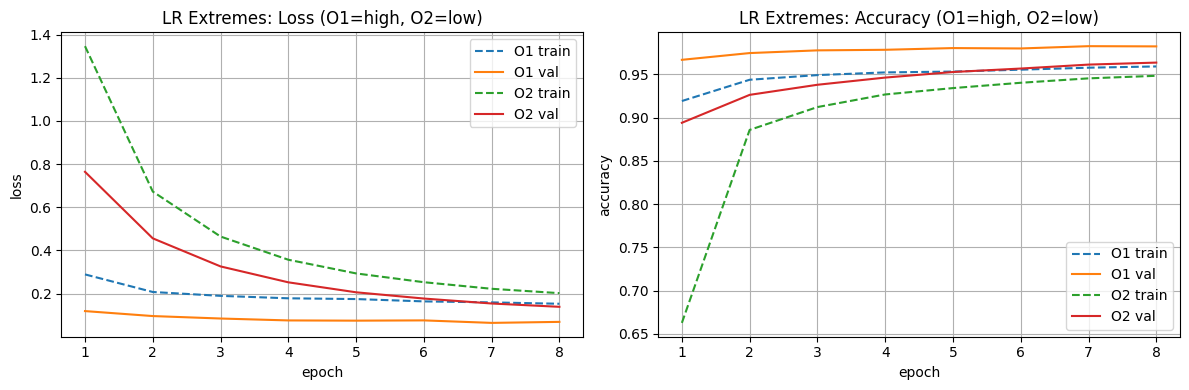

In [6]:
# 6. ЭКСПЕРИМЕНТЫ ЧАСТИ B (S09): ОПТИМИЗАЦИЯ

# O1: LR слишком большой
print('\n' + '='*60)
print('O1: LR Too High (Adam lr=0.1)')
print('='*60)

set_seed()
model_o1 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=use_bn).to(DEVICE)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)
history_o1 = fit(model_o1, train_loader, val_loader, optimizer_o1, criterion, DEVICE, epochs=8, verbose=True)

all_results.append({
    'experiment_id': 'O1', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': '256-128/relu/DO0.3/BN' if use_bn else '256-128/relu/DO0.3/noBN',
    'optimizer': 'Adam', 'lr': 0.1, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': 8, 'best_val_accuracy': max(history_o1['val_acc']),
    'best_val_loss': min(history_o1['val_loss']), 'test_accuracy': 0.0
})

# O2: LR слишком маленький
print('\n' + '='*60)
print('O2: LR Too Low (Adam lr=1e-5)')
print('='*60)

set_seed()
model_o2 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=use_bn).to(DEVICE)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
history_o2 = fit(model_o2, train_loader, val_loader, optimizer_o2, criterion, DEVICE, epochs=8, verbose=True)

all_results.append({
    'experiment_id': 'O2', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': '256-128/relu/DO0.3/BN' if use_bn else '256-128/relu/DO0.3/noBN',
    'optimizer': 'Adam', 'lr': 1e-5, 'momentum': 0, 'weight_decay': 0,
    'epochs_trained': 8, 'best_val_accuracy': max(history_o2['val_acc']),
    'best_val_loss': min(history_o2['val_loss']), 'test_accuracy': 0.0
})

# O3: SGD + momentum + weight_decay
print('\n' + '='*60)
print('O3: SGD + momentum + weight_decay')
print('='*60)

set_seed()
model_o3 = MLP(INPUT_DIM, NUM_CLASSES, hidden_dims=(256, 128), dropout_p=0.3, use_batchnorm=use_bn).to(DEVICE)
optimizer_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
history_o3 = fit(model_o3, train_loader, val_loader, optimizer_o3, criterion, DEVICE, epochs=15, verbose=True)
test_loss_o3, test_acc_o3 = evaluate(model_o3, test_loader, criterion, DEVICE)

all_results.append({
    'experiment_id': 'O3', 'dataset': 'EMNIST', 'seed': SEED,
    'model_summary': '256-128/relu/DO0.3/BN' if use_bn else '256-128/relu/DO0.3/noBN',
    'optimizer': 'SGD', 'lr': 1e-2, 'momentum': 0.9, 'weight_decay': 1e-4,
    'epochs_trained': 15, 'best_val_accuracy': max(history_o3['val_acc']),
    'best_val_loss': min(history_o3['val_loss']), 'test_accuracy': test_acc_o3
})
print(f'O3 Test: acc={test_acc_o3:.4f}')

# График O1/O2
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_o1['epochs'], history_o1['train_loss'], label='O1 train', linestyle='--')
plt.plot(history_o1['epochs'], history_o1['val_loss'], label='O1 val')
plt.plot(history_o2['epochs'], history_o2['train_loss'], label='O2 train', linestyle='--')
plt.plot(history_o2['epochs'], history_o2['val_loss'], label='O2 val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('LR Extremes: Loss (O1=high, O2=low)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_o1['epochs'], history_o1['train_acc'], label='O1 train', linestyle='--')
plt.plot(history_o1['epochs'], history_o1['val_acc'], label='O1 val')
plt.plot(history_o2['epochs'], history_o2['train_acc'], label='O2 train', linestyle='--')
plt.plot(history_o2['epochs'], history_o2['val_acc'], label='O2 val')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('LR Extremes: Accuracy (O1=high, O2=low)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'curves_lr_extremes.png'), dpi=150)
print(f'Saved: {FIGURES_DIR}/curves_lr_extremes.png')
plt.show()

In [7]:
# 7. СОХРАНЕНИЕ runs.csv

df_results = pd.DataFrame(all_results)
df_results.to_csv(os.path.join(ARTIFACTS_DIR, 'runs.csv'), index=False)
print(f'\nSaved: {ARTIFACTS_DIR}/runs.csv')
print('\n' + '='*60)
print('ALL EXPERIMENTS ARE FINISHED')
print('='*60)
print(df_results[['experiment_id', 'optimizer', 'lr', 'best_val_accuracy', 'test_accuracy']].to_string(index=False))


Saved: ./artifacts/runs.csv

ALL EXPERIMENTS ARE FINISHED
experiment_id optimizer      lr  best_val_accuracy  test_accuracy
           E1      Adam 0.00100           0.988313       0.987195
           E2      Adam 0.00100           0.987563       0.988094
           E3      Adam 0.00100           0.990521       0.990840
           E4      Adam 0.00100           0.990333       0.989367
           O1      Adam 0.10000           0.982688       0.000000
           O2      Adam 0.00001           0.963688       0.000000
           O3       SGD 0.01000           0.990417       0.990315
